In [331]:
# NOTES
# use weighted mean!

In [332]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import healpy as hp
import scipy.constants as const

In [333]:
SAVE_FIGS = False

L_BOUNDS = [16, 32] # degrees
B_BOUNDS = [-1.5, 1.5] # degrees

LINUX_DIRECTORY = "/home/aimee/mphys"
FIGURE_SAVEDIR = "figures"
COORD_FILE_NAME = "/home/aimee/mphys/data/wolf_rayet_coords.csv"
MAPS_DIR = "/home/aimee/mphys/data/maps"

COMAP_MAPS = { # name : [file name, frequency / Hz]
    "COMAP 26.5 GHz" : ["comap_alr-2_galactic_301025_band00_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 26.5e9],
    "COMAP 27.5 GHz" : ["comap_alr-2_galactic_301025_band01_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 27.5e9],
    "COMAP 28.5 GHz" : ["comap_alr-2_galactic_301025_band02_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 28.5e9],
    "COMAP 29.5 GHz" : ["comap_alr-2_galactic_301025_band03_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 29.5e9],
    "COMAP 30.5 GHz" : ["comap_alr-2_galactic_301025_band04_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 30.5e9],
    "COMAP 31.5 GHz" : ["comap_alr-2_galactic_301025_band05_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 31.5e9],
    "COMAP 32.5 GHz" : ["comap_alr-2_galactic_301025_band06_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 32.5e9],
    "COMAP 33.5 GHz" : ["comap_alr-2_galactic_301025_band07_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 33.5e9]
}


In [334]:
def get_wr_data():

    data = np.genfromtxt(COORD_FILE_NAME, delimiter=',', skip_header = 1)
    l_coords = data[:,0] # deg
    b_coords = data[:,1] # deg
    distance_arr = data[:,2] # kpc
    
    return l_coords, b_coords, distance_arr

In [335]:
def cut_wr_data(l_coords, b_coords, distance_arr, l_bounds=[15, 155], b_bounds=[5, -5]):
    # l_bounds and b_bounds default to max COMAP range
   
    mask = (l_coords >= l_bounds[0]) & (l_coords <= l_bounds[1]) & (b_coords >= b_bounds[0]) & (b_coords <= b_bounds[1])
    l_cut = np.array(l_coords)[mask]
    b_cut = np.array(b_coords)[mask]
    distance_cut = np.array(distance_arr)[mask]
    
    return l_cut, b_cut, distance_cut

In [336]:
def get_map(path):
    
    print(f"Getting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data
    header = fits_file[0].header
    wcs = WCS(header)
    try:
        noise = fits_file[3].data # COMAP
    except:
        noise = np.full_like(data, 0) # set zero noise for other maps
        
    return data, noise, header, wcs

In [337]:
def cut_data(data, noise, wcs, header):
    
    lat_min = B_BOUNDS[0]
    lat_max = B_BOUNDS[1]
    long_min = L_BOUNDS[0]
    long_max = L_BOUNDS[1]
    step = header['CDELT2']  # pixel resolution

    start_row = int(header['CRPIX2'] + lat_min / step)
    end_row   = int(header['CRPIX2'] + lat_max / step)
    start_col = int(header['CRPIX1'] + (header['CRVAL1'] - long_max) / step)
    end_col   = int(header['CRPIX1'] + (header['CRVAL1'] - long_min) / step)
    
    # Safety check against invalid indices
    nrows, ncols = data.shape
    start_row = max(0, min(nrows - 1, start_row))
    end_row   = max(0, min(nrows - 1, end_row))
    start_col = max(0, min(ncols - 1, start_col))
    end_col   = max(0, min(ncols - 1, end_col))
    
    # Extract and process submap
    submap = data[start_row:end_row + 1, start_col:end_col + 1].copy()
    submap[submap == 0] = np.nan

    noise_submap = noise[start_row:end_row + 1, start_col:end_col + 1].copy()
    noise_submap[noise_submap == 0] = np.nan

    wcs.wcs.crpix[0] -= start_col
    wcs.wcs.crpix[1] -= start_row
    
    return submap, noise_submap, wcs

In [338]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS):
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = 0 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, marker='o', linestyle='None', markerfacecolor='none', markeredgecolor='red', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_B$ [K]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [339]:
def weighted_mean(values, errors):
    
    weights = 1/errors**2
    weighted_mean = np.sum(values*weights)/np.sum(weights)
    weighted_mean_err = np.sqrt(1/np.sum(weights))

    return weighted_mean, weighted_mean_err

In [340]:
def read_region(data, noise, x_centre, y_centre, radius):
    # x_centre, y_centre, and radius in pixels
    
    SCALE_FACTOR = 2 # times radius

    x_min, x_max = int(np.round(x_centre - SCALE_FACTOR * radius)), int(np.round(x_centre + SCALE_FACTOR * radius))
    y_min, y_max = int(np.round(y_centre - SCALE_FACTOR * radius)), int(np.round(y_centre + SCALE_FACTOR * radius))

    source_pixels = np.array([])
    source_noise_pixels = np.array([])
    bg_pixels = np.array([])
    for x in range(x_min, x_max):
        for y in range(y_min, y_max):
            pixel_distance = np.sqrt((x - x_centre)**2 + (y - y_centre)**2)
            if pixel_distance <= radius: # in source
                source_pixels = np.append(source_pixels, data[y, x])
                source_noise_pixels = np.append(source_noise_pixels, noise[y, x])
            elif pixel_distance <= SCALE_FACTOR * radius: # background ring
                bg_pixels = np.append(bg_pixels, data[y, x])

    # Calculate background mean and std
    bg_avg = np.nanmean(bg_pixels)
    bg_std = np.nanstd(bg_pixels)

    # Calculate average noise in source region
    noise_avg = np.nanmean(source_noise_pixels)

    # Calculate total error
    error = np.sqrt(bg_std**2 + noise_avg**2)

    # Background subtract
    source_pixels_bgsub = np.array(source_pixels) - bg_avg
    sum_bgsub = np.sum(source_pixels_bgsub)

    return sum_bgsub, error

In [341]:
def galactic_to_pixel(l_coords, b_coords, wcs):

    x_coords = []
    y_coords = []
    for i, _ in enumerate(l_coords):
        l = l_coords[i] 
        b = b_coords[i]
        
        x, y = wcs.all_world2pix(float(l), float(b), 0)

        x_coords.append(x)
        y_coords.append(y)

    return x_coords, y_coords

In [342]:
# def brightness_temp_to_flux(temp, temp_err, frequency, solid_angle):
#     # temp in K, freq in Hz, solid angle in sterad
#     # Uncertainties assuming only temperature has uncertainty 
    
#     # Rayleigh-Jeans law (brightness temp to brightness)
#     brightness = 2 * frequency**2 * const.k * temp / const.c**2 # W m^-2 sr^-1 Hz^-1
#     brightness_err = 2 * frequency**2 * const.k * temp_err / const.c**2 # CHECK

#     # Brightness to flux density
#     flux = brightness * solid_angle # W m^-2 Hz^-1
#     flux_err = brightness_err * solid_angle # CHECK

#     # Convert to Jy
#     flux_Jy = flux / 1e-26 # Jy
#     flux_Jy_err = flux_err / 1e-26 # CHECK

#     return flux_Jy, flux_Jy_err

In [343]:
def K_to_Jy_per_pix(temp, frequency, sterad_per_pix):
    # temp in K, freq in Hz, solid angle in sterad
    
    # Rayleigh-Jeans law (brightness temp to brightness)
    brightness = 2 * frequency**2 * const.k * temp / const.c**2 # W m^-2 sr^-1 Hz^-1

    brightness_pix = brightness * sterad_per_pix # W m^-2 pix^-1 Hz^-1

    # Convert to Jy per pix
    brightness_Jy_per_pix = brightness_pix / 1e-26 # Jy pix^-1

    return brightness_Jy_per_pix


def Jy_per_pix_to_K(brightness_Jy_per_pix, frequency, sterad_per_pix):
    
    brightness_pix = brightness_Jy_per_pix * 1e-26 # W m^-2 Hz^-1 pix^-1
    brightness = brightness_pix / sterad_per_pix # W m^-2 Hz^-1 sr^-1
    temperature = brightness * const.c**2 / (2 * frequency**2 * const.k) # K

    return temperature

In [344]:
def lattice_plot(map, wcs, l_coords, b_coords, HII_l_coords = None, HII_b_coords=None, brightness_arr=None, brightness_err_arr=None, distance_arr=None):

    x_coords, y_coords = galactic_to_pixel(l_coords, b_coords, wcs)
    if HII_l_coords is not None and HII_b_coords is not None:
        HII_x_coords, HII_y_coords = galactic_to_pixel(HII_l_coords, HII_b_coords, wcs)

    # Initialise plot
    stampsize = 8 # pixels
    n_cutouts = len(x_coords)
    n_rows = int(np.ceil(np.sqrt(n_cutouts)))
    n_cols = int(np.ceil(n_cutouts / n_rows))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.5 * n_rows), dpi=300)
    axes = axes.flatten()
    
    # Loop through sources
    cutout_arr = []
    for i, (x, y, l, b) in enumerate(zip(x_coords, y_coords, l_coords, b_coords)):

        # Define the pixel range for the cutout (ensure it stays within bounds)
        x_min, x_max = max(int(x - 1 - stampsize), 0), min(int(x + stampsize), map.shape[1])
        y_min, y_max = max(int(y - 1 - stampsize), 0), min(int(y + stampsize), map.shape[0])
     
        # Create cutout
        cutout = map[y_min:y_max, x_min:x_max]
        if (cutout.shape[0] == stampsize*2 + 1) & (cutout.shape[1] == stampsize*2 + 1): # can't add arrays of different sizes
            cutout_arr.append(cutout)
        
        # Plot cutout and centre coordinate
        ax = axes[i]
        im = ax.imshow(cutout, origin='lower', cmap='viridis')

        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
        cbar.set_label('Jy / pixel', fontsize=10)

        ax.scatter(x - x_min, y - y_min, color='red', marker='x', linewidth=1)

        if HII_l_coords is not None and HII_b_coords is not None:
            HII_x = HII_x_coords[i]
            HII_y = HII_y_coords[i]
            ax.scatter(HII_x - x_min, HII_y - y_min, color='blue', marker='x', linewidth=1)
        
        title = f"(l, b) = ({l}, {b})"
        if brightness_arr is not None and brightness_err_arr is not None:
            title = f'{title}\n$B$ = {brightness_arr[i]:.3f} ± {brightness_err_arr[i]:.3f} Jy / pixel'
        if distance_arr is not None:
            title = f'{title}\nd = {distance_arr[i]} kpc'
        ax.set_title(title)
        
        ax.set_xlabel("l index [pix]")
        ax.set_ylabel("b index [pix]")

    fig.tight_layout()
    plt.show()

    return cutout_arr


In [345]:
def stacked_plot(cutout_arr, brightness_arr, brightness_err_arr):
    # print(cutout_arr)
    stacked_cutout = np.zeros_like(cutout_arr[0])
    for cutout in cutout_arr:
        for i, row in enumerate(cutout):
            for j, pixel in enumerate(row):
                stacked_cutout[i, j] += float(pixel)  
    # print(stacked_cutout) # DEBUG
    
    stacked_brightness = sum(brightness_arr)
    stacked_brightness_err = np.sqrt(np.sum(brightness_err_arr)**2) # add in quadrature
    mean_brightness, mean_brightness_err = weighted_mean(brightness_arr, brightness_err_arr)
    
    im = plt.imshow(stacked_cutout, origin='lower', cmap='viridis')
    plt.title(f'Stacked plot\nTotal Brightness = {stacked_brightness:.3f} +- {stacked_brightness_err:.3f} Jy/pixel\n\
              Mean Brightness = {mean_brightness:.3f} +- {mean_brightness_err:.4f} Jy/pixel')
    plt.xlabel("l index [pix]")
    plt.ylabel("b index [pix]")
    cbar = plt.colorbar(im)
    cbar.set_label('Jy/pixel', fontsize=10)  # Label the color bar with Temperature [K]
    plt.show()

Getting data from /home/aimee/mphys/data/maps/comap_alr-2_galactic_301025_band07_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits


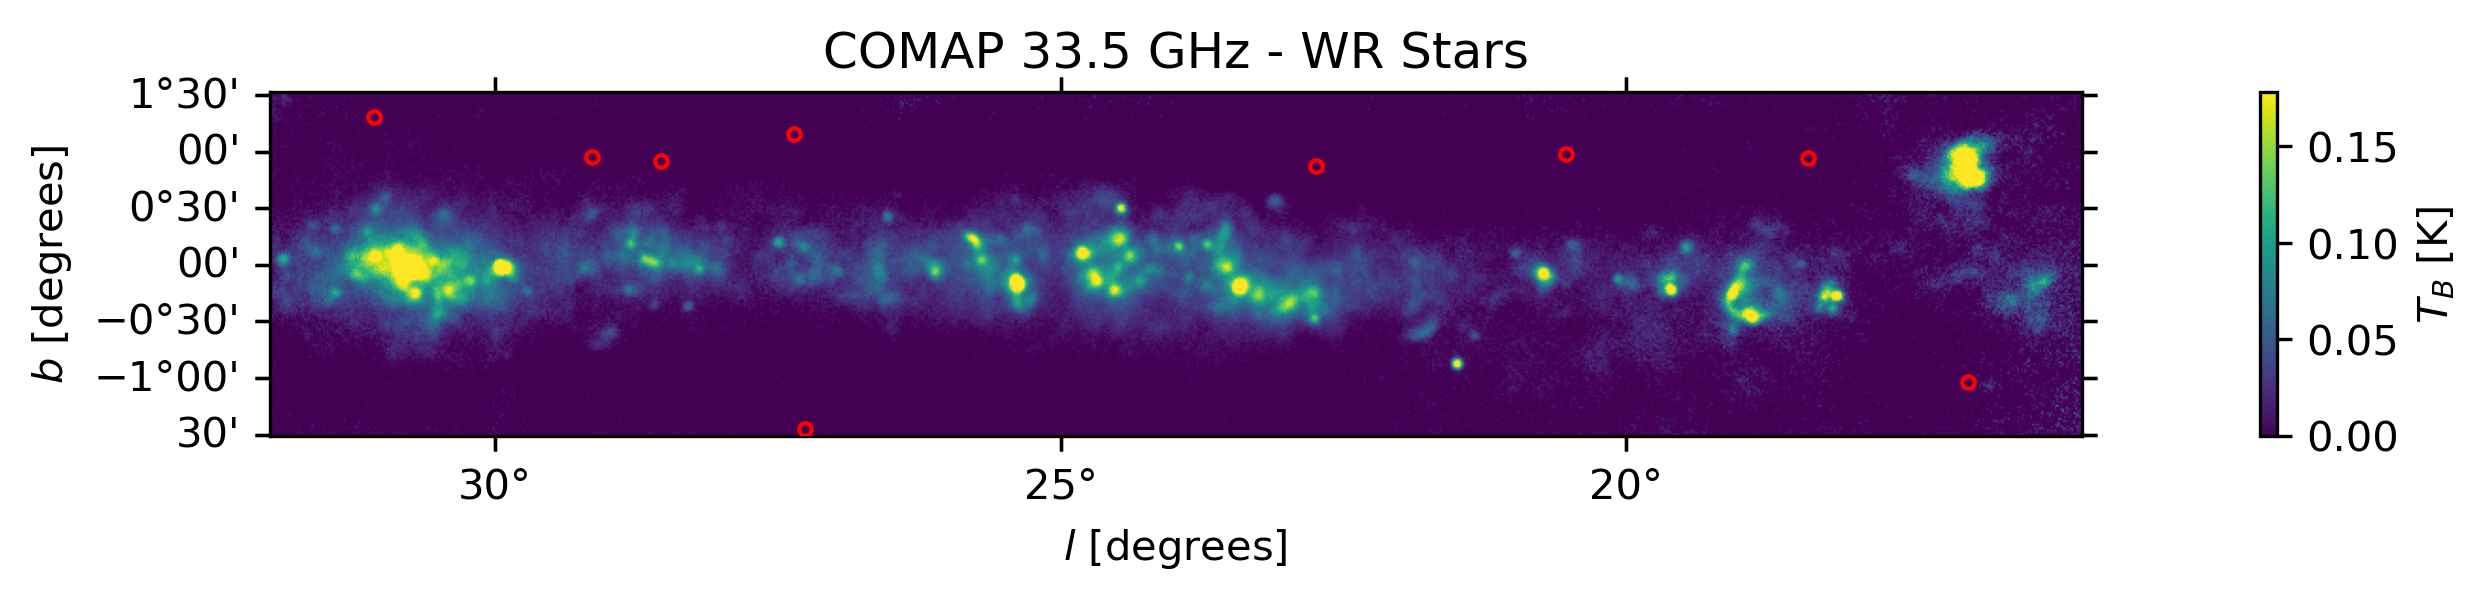

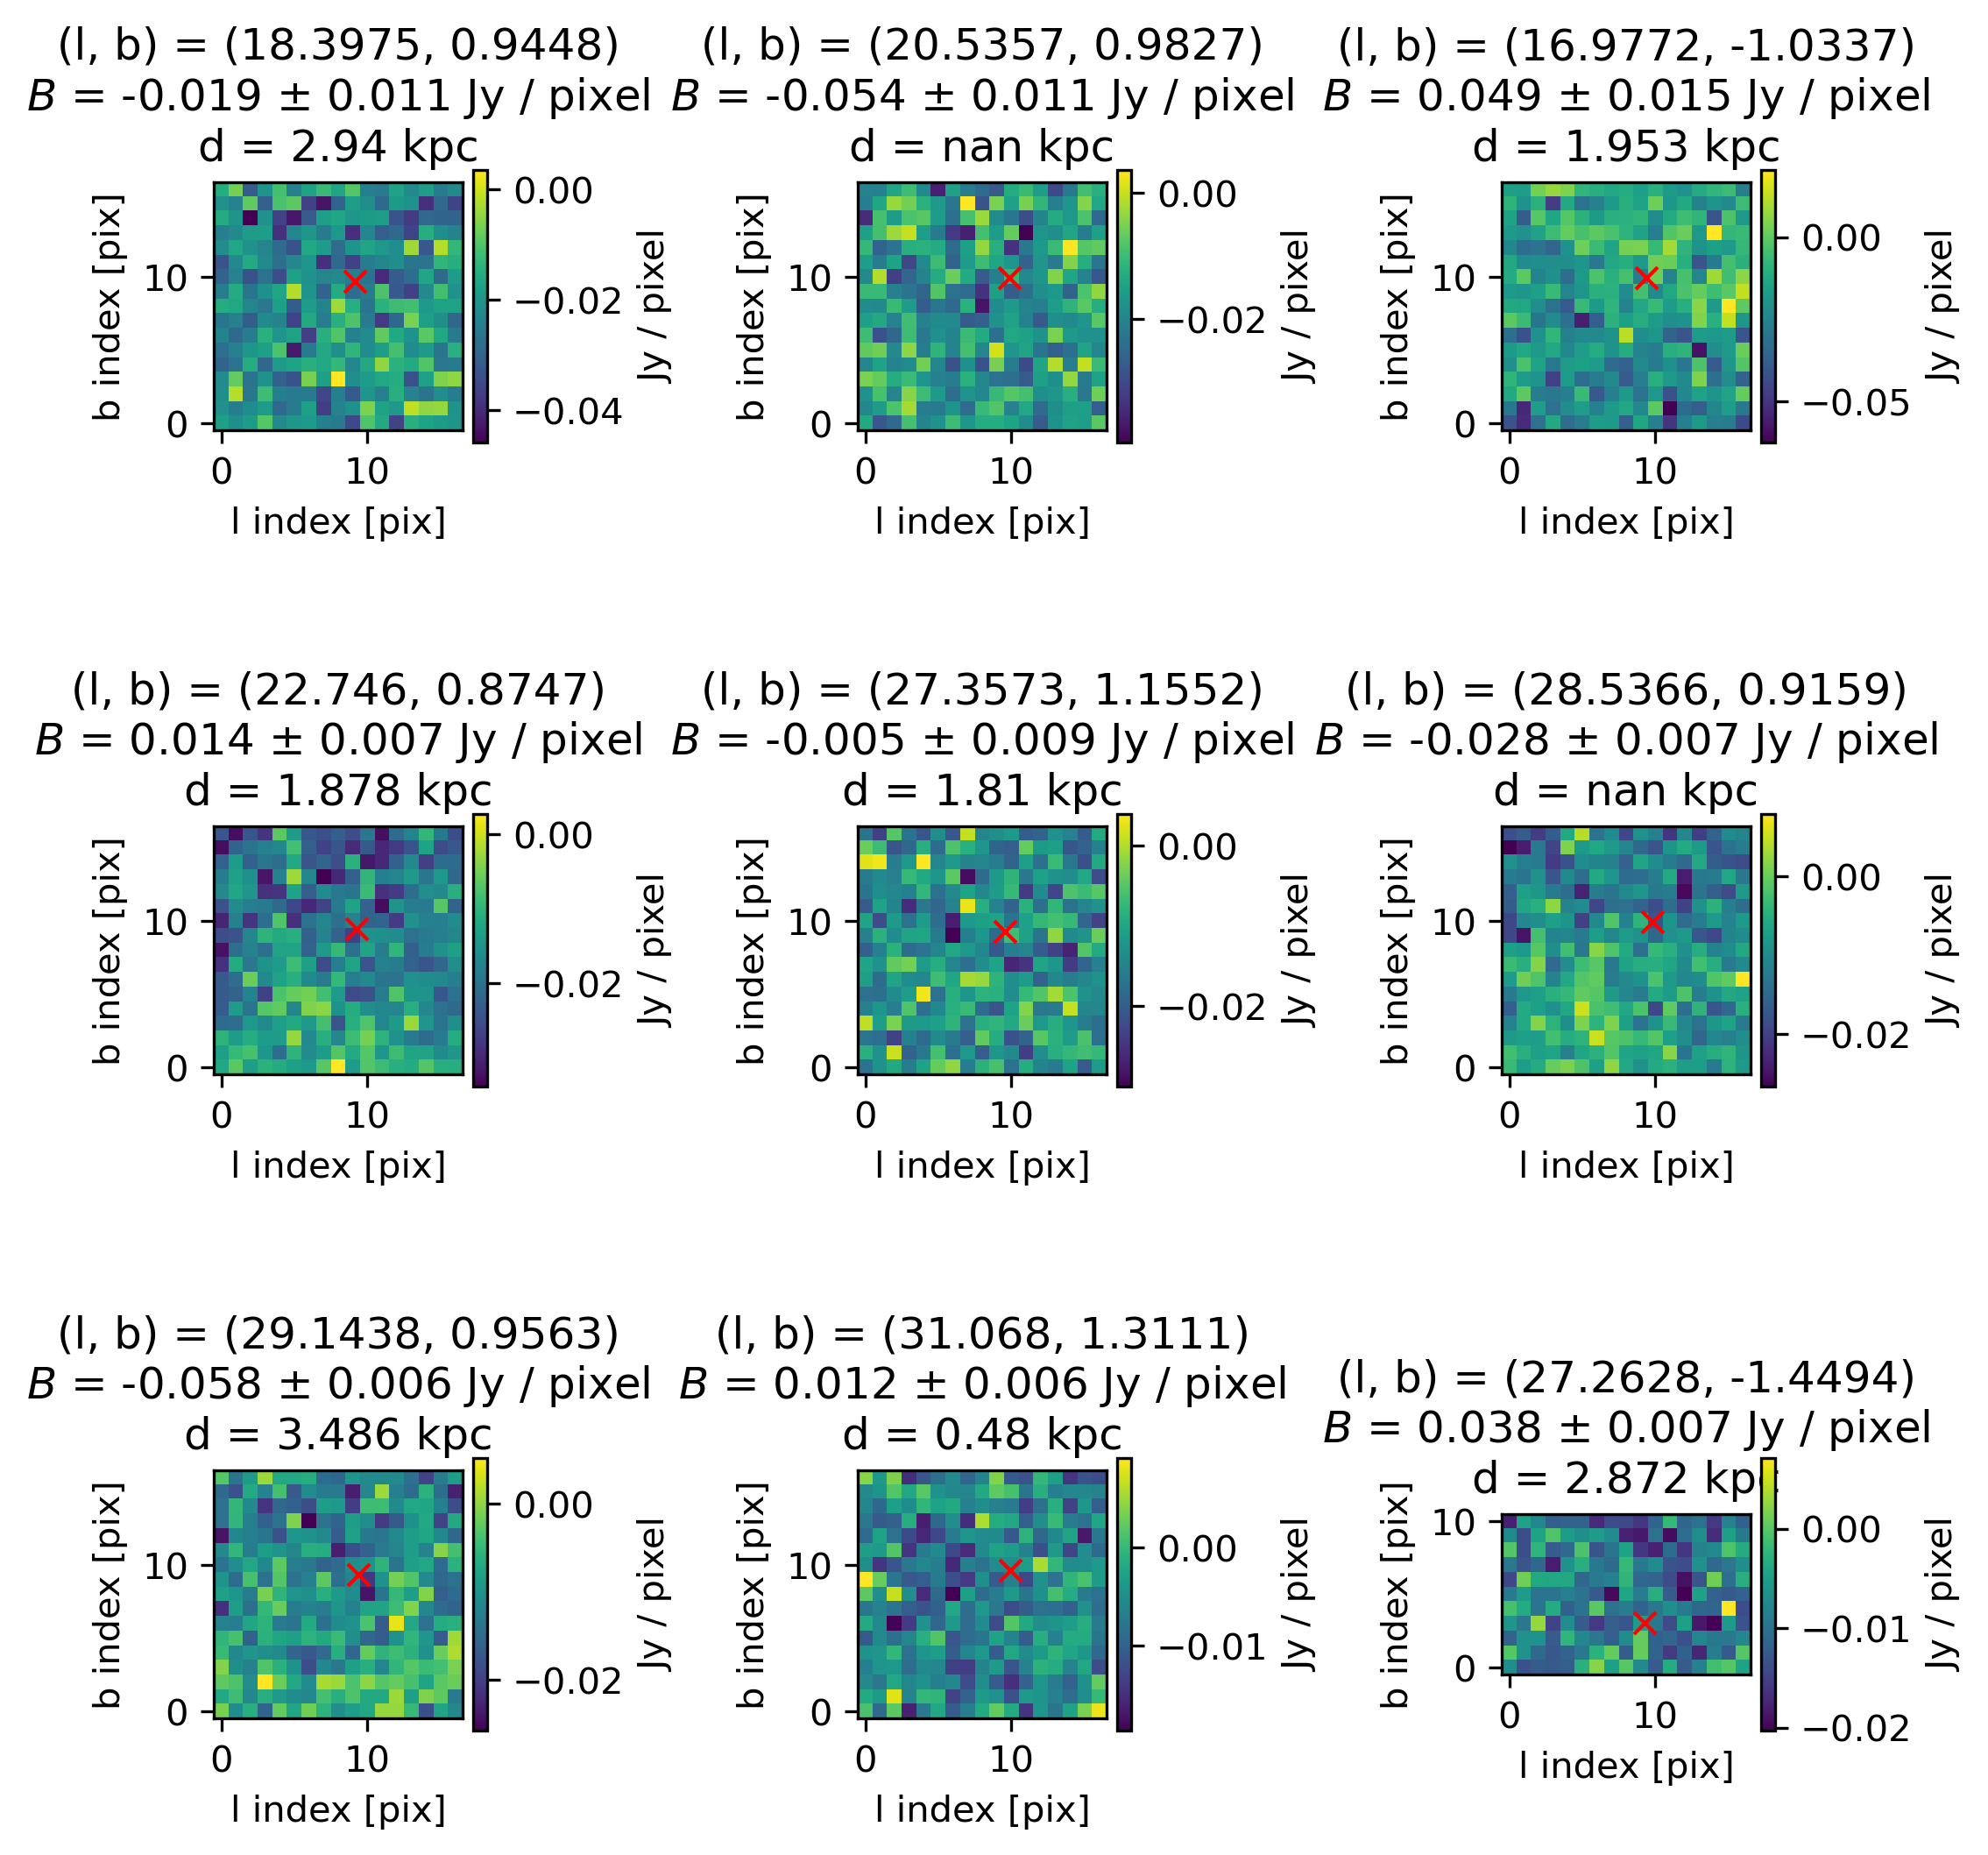

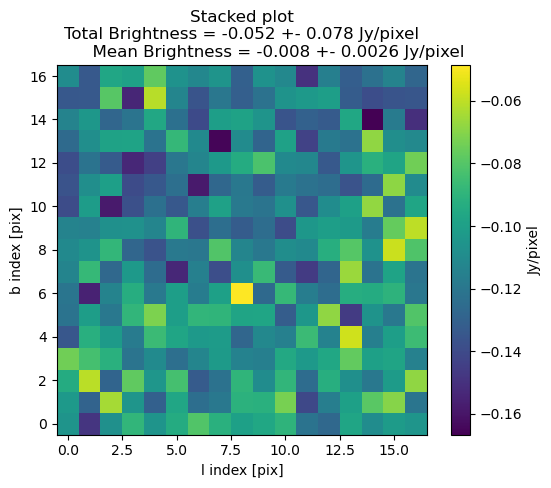


Mean Brightness = -0.00777303 +- 0.00260301 Jy / pixel            
Upper Bound (mean + 3*sigma) = 3.60052e-05 Jy / pixel

Mean Brightness Temperature = -0.00266428 +- 0.000892208 K            
Upper Bound (mean + 3*sigma) = 1.23411e-05 K

c.f. Average noise = 0.00507194 K


In [346]:
# MAIN CODE

# Get WR coordinates
l_coords, b_coords, distance_arr = get_wr_data()
l_coords, b_coords, distance_arr = cut_wr_data(l_coords, b_coords, distance_arr, l_bounds=L_BOUNDS, b_bounds=B_BOUNDS)
radii_arcmin = np.full_like(l_coords, 2.5) # arcmin (since 5 arcmin diameter beam)
radii_pixels = radii_arcmin # (COMAP data is 1 arcmin per pixel so don't have to convert)

# # EITHER: Only points with visible nearby sources - hard coded for 16 < l < 32, -1.5 < b < 1.5
# indices = [
#            # 7, 8,
#             9, 17, 29, 35, 42, 59, 66, 68, 69
#     ] # Possible sources - found by eye
# l_coords = l_coords[indices]
# b_coords = b_coords[indices]
# HII_l_coords = [
#                 # 16.9, 18.2,
#                 18.9, 21.9, 25.8, 0, 0, 0, 31.0, 31.0, 0]
# HII_b_coords = [
#                 # -1.1, -0.3,
#                  -0.4, 0.0, 0.2, 0, 0, 0, 0.0, 0.0, 0]
# HII_diameters = [] # fill later if necessary

# OR: Only points away from plane
indices = []
for i, b in enumerate(b_coords):
    if np.abs(b) >= 0.7: # tweak
        indices.append(i)
# print(indices) # DEBUG
l_coords = l_coords[indices]
b_coords = b_coords[indices]

# map_titles = list(COMAP_MAPS.keys())
map_titles = ["COMAP 33.5 GHz"] # TEMP - loop through all files later

for map_title in map_titles:

    map_fname = COMAP_MAPS[map_title][0]
    map_freq = COMAP_MAPS[map_title][1]
    map_path = f'{MAPS_DIR}/{map_fname}'

    # # TEMP - try high frequency map
    # map_title = 'IRIS 25 THz'
    # map_fname = 'IRIS-25000.0GHz-5.0amin.fits'
    # map_freq = 25e12
    # map_path = f'/home/aimee/mphys/data/maps_old/{map_fname}'
    # # \TEMP
    
    # Read in and cut map
    data, noise, header, wcs = get_map(map_path)
    data, noise, wcs = cut_data(data, noise, wcs, header)
    
    cdelt_deg = np.abs(header['CDELT2'])
    cdelt_rad = cdelt_deg * np.pi/180
    sterad_per_pix = cdelt_rad**2
    # print(f'Degrees: {cdelt_deg}, Rad: {cdelt_rad}, sterad:{sterad_per_pix}') # DEBUG
    
    data = K_to_Jy_per_pix(data, map_freq, sterad_per_pix)
    noise = K_to_Jy_per_pix(noise, map_freq, sterad_per_pix)

    # Plot WR locations on map
    x_coords, y_coords = galactic_to_pixel(l_coords, b_coords, wcs)
    plot_fits(data, wcs, title=f'{map_title} - WR Stars', x_coords=x_coords, y_coords=y_coords, save_figs=False)

    # Calculate brightness
    brightness_arr, brightness_err_arr = [], []
    for x, y, radius in zip(x_coords, y_coords, radii_pixels):
        brightness, brightness_err = read_region(data, noise, x, y, radius)
        brightness_arr.append(brightness)
        brightness_err_arr.append(brightness_err)
    brightness_arr, brightness_err_arr = np.array(brightness_arr), np.array(brightness_err_arr)
    # print(f'Brightness [Jy / pixel] : {brightness_arr}')
    
    # Lattice plot of WR stars
    cutout_arr = lattice_plot(data, wcs, l_coords, b_coords, 
                # HII_l_coords, HII_b_coords,
                brightness_arr=brightness_arr, brightness_err_arr=brightness_err_arr,
                distance_arr=distance_arr)
    
    # Optional: stacked plot 
    stacked_plot(cutout_arr, brightness_arr, brightness_err_arr)

    # Print final results in Jy/pixel and K
    mean_brightness, mean_brightness_err = weighted_mean(brightness_arr, brightness_err_arr)
    print(f'\nMean Brightness = {mean_brightness:g} +- {mean_brightness_err:g} Jy / pixel\
            \nUpper Bound (mean + 3*sigma) = {mean_brightness + 3*mean_brightness_err:g} Jy / pixel')
    
    mean_temp = Jy_per_pix_to_K(mean_brightness, map_freq, sterad_per_pix)
    mean_temp_err = Jy_per_pix_to_K(mean_brightness_err, map_freq, sterad_per_pix) 
    print(f'\nMean Brightness Temperature = {mean_temp:g} +- {mean_temp_err:g} K\
            \nUpper Bound (mean + 3*sigma) = {mean_temp + 3*mean_temp_err:g} K')
    
    print(f'\nc.f. Average noise = {np.nanmean(noise):g} K')